In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

PROJECT_ROOT = Path.cwd().parent

In [ ]:
# Configuração dos diretórios do projeto.
# Os dados balanceados vêm da etapa anterior de normalização/padronização e SMOTE.
# As figuras, tabelas e modelos treinados serão salvos nas pastas padronizadas do projeto.

BALANCED_DIR = PROJECT_ROOT / "data" / "balanced"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"
MODELS_DIR = PROJECT_ROOT / "models"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
# Carregamento das bases finais para modelagem.
# A base de treino está padronizada e balanceada com SMOTE.
# A base de teste está apenas padronizada, mantendo a distribuição original das classes.

train_df = pd.read_csv(BALANCED_DIR / "wine_quality_train_standard_smote.csv")
test_df = pd.read_csv(BALANCED_DIR / "wine_quality_test_standard.csv")

X_train = train_df.drop(columns=["quality_binary"])
y_train = train_df["quality_binary"]

X_test = test_df.drop(columns=["quality_binary"])
y_test = test_df["quality_binary"]

In [ ]:
# Treinamento dos modelos de classificação.
# A Regressão Logística funciona como modelo linear simples.
# O Random Forest funciona como modelo mais robusto, capaz de capturar relações não lineares.

logistic_model = LogisticRegression(
    random_state=42,
    solver="liblinear"
)

random_forest_model = RandomForestClassifier(
    random_state=42,
    n_estimators=100
)

logistic_model.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)

logistic_preds = logistic_model.predict(X_test)
random_forest_preds = random_forest_model.predict(X_test)

In [ ]:
# Comparação das métricas dos modelos.
# Accuracy mostra o acerto geral.
# Precision mostra, entre os vinhos previstos como alta qualidade, quantos realmente eram alta qualidade.
# Recall mostra, entre os vinhos realmente de alta qualidade, quantos o modelo conseguiu encontrar.
# F1-score equilibra precision e recall, sendo uma boa métrica para classes desbalanceadas.

resultados = []

modelos = {
    "Regressão Logística": logistic_preds,
    "Random Forest": random_forest_preds
}

for nome_modelo, y_pred in modelos.items():
    resultados.append({
        "modelo": nome_modelo,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred)
    })

metricas_df = pd.DataFrame(resultados).sort_values(by="f1_score", ascending=False)

metricas_df.to_csv(TABLES_DIR / "metricas_modelos_classificacao.csv", index=False)

metricas_df

,modelo,accuracy,precision,recall,f1_score
1,Random Forest,0.892157,0.575758,0.703704,0.633333
0,Regressão Logística,0.794118,0.363636,0.740741,0.487805


In [ ]:
# Salvando os modelos treinados.
# Esses arquivos podem ser carregados posteriormente sem precisar treinar novamente.

joblib.dump(logistic_model, MODELS_DIR / "logistic_regression.pkl")
joblib.dump(random_forest_model, MODELS_DIR / "random_forest.pkl")

['/Users/assis/Documents/Jacque/FIAP/FASE02/projeto/Tech-Challenge-FIAP-Fase-2---Wine-Quality/models/random_forest.pkl']

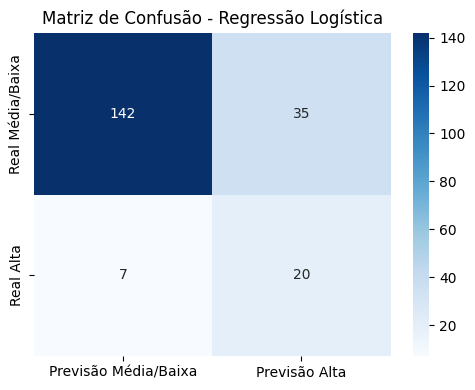

In [18]:
# Matriz de confusão para Regressão Logística:

conf_matrix_log = confusion_matrix(y_test, logistic_preds)

plt.figure(figsize=(5, 4))
sns.heatmap(
    conf_matrix_log,
    annot=True,
    cmap="Blues",
    fmt="d",
    xticklabels=["Previsão Média/Baixa", "Previsão Alta"],
    yticklabels=["Real Média/Baixa", "Real Alta"]
)

plt.title("Matriz de Confusão - Regressão Logística")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "matriz_confusao_logistica.png", bbox_inches="tight")
plt.show()

In [21]:
# Relatório detalhado da Regressão Logística

print("Relatório - Regressão Logística")
print(classification_report(
    y_test,
    logistic_preds,
    target_names=["Média/Baixa", "Alta"]
))

Relatório - Regressão Logística
              precision    recall  f1-score   support

 Média/Baixa       0.95      0.80      0.87       177
        Alta       0.36      0.74      0.49        27

    accuracy                           0.79       204
   macro avg       0.66      0.77      0.68       204
weighted avg       0.88      0.79      0.82       204



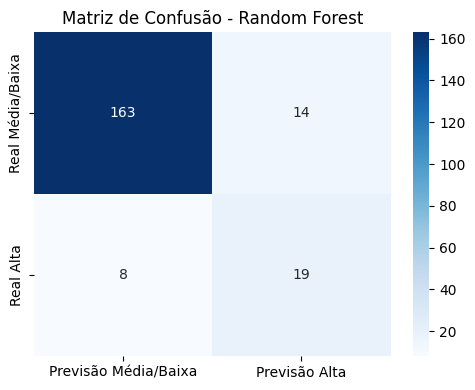

In [ ]:
# Matriz de confusão para Random Forest.
# Mostra os acertos e erros do modelo em cada classe.

conf_matrix_rf = confusion_matrix(y_test, random_forest_preds)

plt.figure(figsize=(5, 4))
sns.heatmap(
    conf_matrix_rf,
    annot=True,
    cmap="Blues",
    fmt="d",
    xticklabels=["Previsão Média/Baixa", "Previsão Alta"],
    yticklabels=["Real Média/Baixa", "Real Alta"]
)

plt.title("Matriz de Confusão - Random Forest")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "matriz_confusao_random_forest.png", bbox_inches="tight")

plt.show()

In [22]:
# Relatório detalhado do Random Forest

print("Relatório - Random Forest")
print(classification_report(
    y_test,
    random_forest_preds,
    target_names=["Média/Baixa", "Alta"]
))

Relatório - Random Forest
              precision    recall  f1-score   support

 Média/Baixa       0.95      0.92      0.94       177
        Alta       0.58      0.70      0.63        27

    accuracy                           0.89       204
   macro avg       0.76      0.81      0.79       204
weighted avg       0.90      0.89      0.90       204



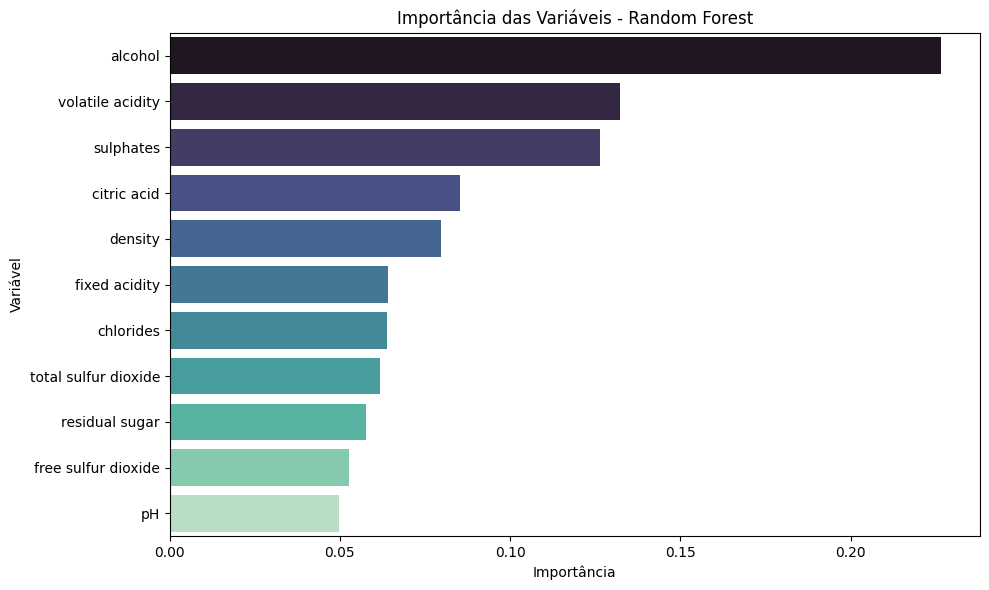

In [20]:
# Importância de variáveis:

importances = random_forest_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "variavel": X_train.columns,
    "importancia": importances
}).sort_values(by="importancia", ascending=False)

feature_importance_df.to_csv(
    TABLES_DIR / "importancia_variaveis_random_forest.csv",
    index=False
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance_df,
    x="importancia",
    y="variavel",
    hue="variavel",
    palette="mako",
    legend=False
)

plt.title("Importância das Variáveis - Random Forest")
plt.xlabel("Importância")
plt.ylabel("Variável")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "importancia_variaveis_random_forest.png", bbox_inches="tight")
plt.show()